### Functions and Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

### DataSet

In [33]:
customers = pd.read_csv("dataset/olist_customers_dataset.csv")
orders = pd.read_csv("dataset/olist_orders_dataset.csv")
order_items = pd.read_csv("dataset/olist_order_items_dataset.csv")
payments = pd.read_csv("dataset/olist_order_payments_dataset.csv")
reviews = pd.read_csv("dataset/olist_order_reviews_dataset.csv")
products = pd.read_csv("dataset/olist_products_dataset.csv")
geolocation = pd.read_csv("dataset/olist_geolocation_dataset.csv")
product_category = pd.read_csv("dataset/product_category_name_translation.csv")

## Data Modelling and Data Cleaning

### Dataframes Core

In [34]:
orders_df = orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_customer_date']]

orders_per_customer = orders_df.groupby('customer_id').size().reset_index(name='num_orders')

order_items_payments = order_items.merge(orders, on='order_id')
order_items_payments = order_items_payments.merge(payments, on='order_id')

orders_items_payments_agg = (
    order_items_payments.groupby('customer_id')
    .agg(
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        payment_type_count=('payment_type', 'nunique')
    )
    .reset_index()
)

# Avaliações médias
reviews_avg = reviews.merge(orders, on='order_id')
reviews_avg = reviews_avg.groupby('customer_id')['review_score'].mean().reset_index(name='avg_review_score')

# Tempo médio de entrega
orders['delivery_days'] = pd.to_datetime(orders['order_delivered_customer_date']) - pd.to_datetime(orders['order_purchase_timestamp'])
orders['delivery_days'] = orders['delivery_days'].dt.days
orders_delivery_time = orders.groupby('customer_id')['delivery_days'].mean().reset_index(name='avg_delivery_days')

### Dataframe Final

In [44]:
customers_final = customers.merge(orders_per_customer, on='customer_id', how='inner')
customers_final = customers_final.merge(orders_items_payments_agg, on='customer_id', how='left')
customers_final = customers_final.merge(reviews_avg, on='customer_id', how='left')
customers_final = customers_final.merge(orders_delivery_time, on='customer_id', how='left')

#Remoção de colunas com variáveis categóricas que não vou usar
cols_to_drop = ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city']
available_cols_to_drop = [col for col in cols_to_drop if col in customers_final.columns]

if available_cols_to_drop:
    customers_final = customers_final.drop(columns=available_cols_to_drop)

In [45]:
print(customers_final)

      customer_state  num_orders  total_price  total_freight  \
0                 SP           1       124.99          21.88   
1                 SP           1       289.00          46.48   
2                 SP           1       139.94          17.79   
3                 SP           1       149.94          23.36   
4                 SP           1       230.00          22.25   
...              ...         ...          ...            ...   
99436             SP           1        74.90          13.88   
99437             SP           1       114.90          14.16   
99438             CE           1        37.00          19.04   
99439             RS           1       689.00          22.07   
99440             SP           1        13.99           7.78   

       payment_type_count  avg_review_score  avg_delivery_days  
0                     1.0               4.0                8.0  
1                     1.0               5.0               16.0  
2                     1.0           

### Tratamento de variáveis categóricas

In [51]:
categorical_cols = ['customer_state']
numerical_cols = [col for col in customers_final.columns if col not in categorical_cols]

for col in numerical_cols:
    customers_final[col] = pd.to_numeric(customers_final[col], errors='coerce')
    
customers_final[numerical_cols] = customers_final[numerical_cols].fillna(0)

# Transformando as categóricas em numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('state', OneHotEncoder(handle_unknown='ignore'), ['customer_state']),
    ],
    remainder='passthrough',
    sparse_threshold=0
)

X = preprocessor.fit_transform(customers_final)

# Padronizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Data Science

### Método do Cotovelo (Elbow)

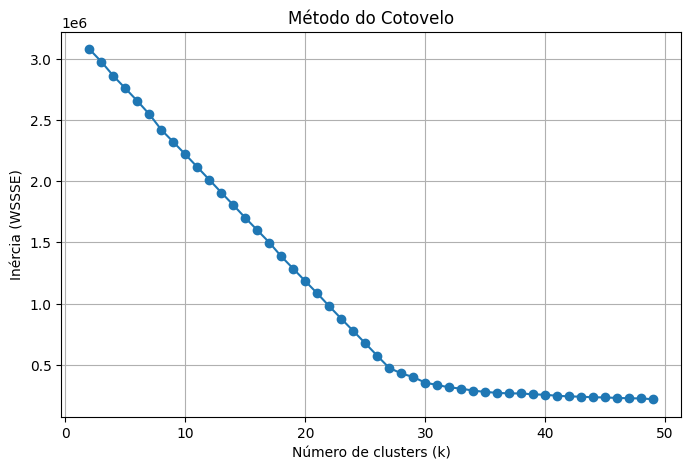

In [60]:
inertias = []
ks = range(2, 50)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia (WSSSE)')
plt.title('Método do Cotovelo')
plt.grid(True)
plt.show()

### KMeans para Clusterização

In [62]:
kmeans = KMeans(n_clusters=25, random_state=1)
clusters = kmeans.fit_predict(X_scaled)

customers_final["cluster"] = clusters

### Plotagem em 2D

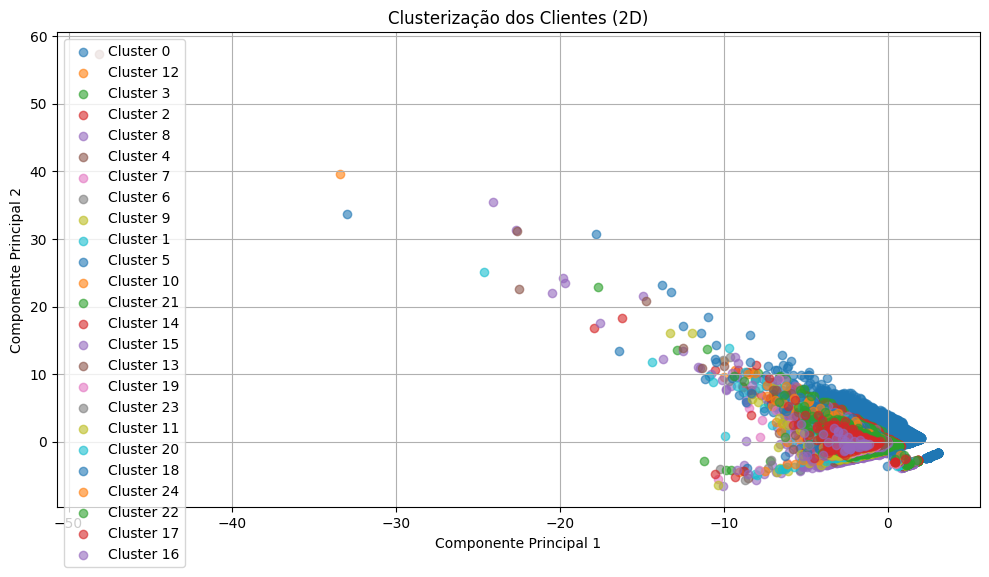

In [63]:
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

df_pca_2d = pd.DataFrame(X_pca_2d, columns=["x", "y"])
df_pca_2d["cluster"] = clusters

# Plotar gráfico 2D
plt.figure(figsize=(10, 6))

for cluster_id in df_pca_2d["cluster"].unique():
    subset = df_pca_2d[df_pca_2d["cluster"] == cluster_id]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {cluster_id}", alpha=0.6)

plt.title("Clusterização dos Clientes (2D)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Plotagem em 3D

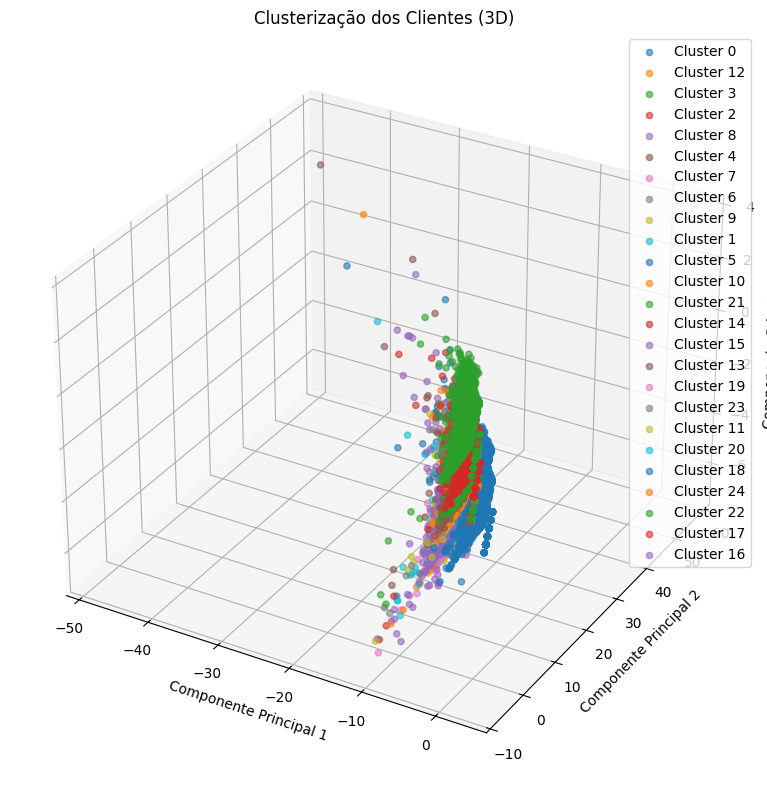

In [64]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["x", "y", "z"])
df_pca["cluster"] = clusters

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster_id in df_pca["cluster"].unique():
    subset = df_pca[df_pca["cluster"] == cluster_id]
    ax.scatter(subset["x"], subset["y"], subset["z"], label=f"Cluster {cluster_id}", alpha=0.6)

ax.set_title("Clusterização dos Clientes (3D)")
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.set_zlabel("Componente Principal 3")
ax.legend()
plt.tight_layout()
plt.show()